# Problem 5: House Price Prediction with Google TabFM

## Problem
A real-estate platform needs accurate property value estimates for buyers and sellers.

## What to do
Predict the **selling price** of each property.

## Goals
- Improve pricing accuracy
- Help buyers/sellers make informed decisions
- Power automated valuation tools

Target: `SalePrice` (continuous)

This notebook is production-oriented: reproducible setup, direct web download, robust preprocessing, strong baseline + TabFM variants, and deployable artifacts.

## 0) Why this design

### Dataset
We use the canonical **Ames House Prices** dataset directly from OpenML (web download in-notebook):
- OpenML dataset id: `42165`
- Name: `house_prices`
- Target: `SalePrice`

### Feature coverage
This dataset includes many real-estate signals aligned with your requirement:
- Size: `GrLivArea`, `LotArea`, `TotalBsmtSF`, floor areas
- Rooms: bedroom/bath counts
- Location proxies: `Neighborhood`, `MSZoning`
- Property age/quality: `YearBuilt`, `YearRemodAdd`, `OverallQual`
- Nearby-quality proxies: neighborhood/quality-related categorical variables

### Modeling strategy
- Baseline: XGBoost Regressor
- Foundation model: Google TabFM Regressor (3 variants)
- Evaluation priority: RMSE/MAE/R2 + uncertainty-aware pricing bands

## 1) Reproducible setup

Optional environment variables:

- `TABFM_DEVICE=auto|cpu|cuda`
- `OPENML_DATA_ID=42165`
- `HP_SAMPLE_TRAIN_ROWS=0` (0 means full split)
- `HP_SAMPLE_EVAL_ROWS=0` (0 means full val/test)
- `HP_MIN_SAMPLE_ROWS=150`
- `TABFM_CONTEXT_MAX_ROWS=700`
- `TABFM_EVAL_MAX_ROWS=0` (0 means full val/test for model comparison)
- `TABFM_FAST_MODE=0|1` (1 for constrained runtime)
- `TABFM_CHECKPOINT_PATH=/abs/path/to/model_or_repo_root` (optional)

License note:
- TabFM code is Apache-2.0.
- TabFM released weights are non-commercial; review terms before commercial use.

In [1]:
from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import torch
from loguru import logger
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TABFM_DEVICE_PREF = os.getenv('TABFM_DEVICE', 'auto').lower().strip()
if TABFM_DEVICE_PREF not in {'auto', 'cpu', 'cuda'}:
    raise ValueError(f'Unsupported TABFM_DEVICE={TABFM_DEVICE_PREF}')

OPENML_DATA_ID = int(os.getenv('OPENML_DATA_ID', '42165'))
SAMPLE_TRAIN_ROWS = int(os.getenv('HP_SAMPLE_TRAIN_ROWS', '0'))
SAMPLE_EVAL_ROWS = int(os.getenv('HP_SAMPLE_EVAL_ROWS', '0'))
MIN_SAMPLE_ROWS = int(os.getenv('HP_MIN_SAMPLE_ROWS', '150'))
TABFM_CONTEXT_MAX_ROWS = int(os.getenv('TABFM_CONTEXT_MAX_ROWS', '700'))
TABFM_EVAL_MAX_ROWS = int(os.getenv('TABFM_EVAL_MAX_ROWS', '0'))
TABFM_FAST_MODE = os.getenv('TABFM_FAST_MODE', '0').strip() == '1'
TABFM_CHECKPOINT_OVERRIDE = os.getenv('TABFM_CHECKPOINT_PATH', '').strip()

if SAMPLE_TRAIN_ROWS != 0 and SAMPLE_TRAIN_ROWS <= MIN_SAMPLE_ROWS:
    raise ValueError(f'HP_SAMPLE_TRAIN_ROWS must be 0 or > {MIN_SAMPLE_ROWS}')
if SAMPLE_EVAL_ROWS != 0 and SAMPLE_EVAL_ROWS <= MIN_SAMPLE_ROWS:
    raise ValueError(f'HP_SAMPLE_EVAL_ROWS must be 0 or > {MIN_SAMPLE_ROWS}')
if TABFM_CONTEXT_MAX_ROWS <= 200:
    raise ValueError('TABFM_CONTEXT_MAX_ROWS must be > 200.')
if TABFM_EVAL_MAX_ROWS != 0 and TABFM_EVAL_MAX_ROWS <= 100:
    raise ValueError('TABFM_EVAL_MAX_ROWS must be 0 or > 100.')


def resolve_tabfm_device(preference: str) -> str:
    if preference == 'auto':
        return 'cuda' if torch.cuda.is_available() else 'cpu'
    if preference == 'cuda' and not torch.cuda.is_available():
        logger.warning('TABFM_DEVICE=cuda requested but CUDA unavailable; falling back to cpu')
        return 'cpu'
    return preference


def find_project_root(start: Path) -> Path:
    for cand in [start, *start.parents]:
        if (cand / 'pyproject.toml').exists():
            return cand
    raise RuntimeError('Could not find project root (pyproject.toml not found).')


PROJECT_ROOT = find_project_root(Path.cwd())
PROBLEM_ROOT = PROJECT_ROOT / 'problems' / 'problem5_house_price_prediction'
DATA_DIR = PROBLEM_ROOT / 'data' / 'raw'
ARTIFACT_DIR = PROBLEM_ROOT / 'artifacts'

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = resolve_tabfm_device(TABFM_DEVICE_PREF)
TABFM_CKPT_PATH = Path(TABFM_CHECKPOINT_OVERRIDE) if TABFM_CHECKPOINT_OVERRIDE else None

logger.info('Project root: {}', PROJECT_ROOT)
logger.info('Problem root: {}', PROBLEM_ROOT)
logger.info('Raw data dir: {}', DATA_DIR)
logger.info('Artifacts dir: {}', ARTIFACT_DIR)
logger.info('TabFM device preference={} effective={}', TABFM_DEVICE_PREF, DEVICE)
logger.info('OpenML data id: {}', OPENML_DATA_ID)
logger.info('Sample train/eval rows: {}/{} (0 means full)', SAMPLE_TRAIN_ROWS, SAMPLE_EVAL_ROWS)
logger.info('TabFM context max rows: {}', TABFM_CONTEXT_MAX_ROWS)
logger.info('TabFM eval max rows: {} (0 means full)', TABFM_EVAL_MAX_ROWS)
logger.info('TabFM fast mode: {}', TABFM_FAST_MODE)
logger.info('TabFM checkpoint override: {}', TABFM_CKPT_PATH)

sns.set_theme(style='whitegrid')

2026-07-03 03:57:28.251 | INFO     | __main__:<module>:86 - Project root: /home/ahmad/AI/Github/google-tabFM-implementation


2026-07-03 03:57:28.252 | INFO     | __main__:<module>:87 - Problem root: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem5_house_price_prediction


2026-07-03 03:57:28.252 | INFO     | __main__:<module>:88 - Raw data dir: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem5_house_price_prediction/data/raw


2026-07-03 03:57:28.253 | INFO     | __main__:<module>:89 - Artifacts dir: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem5_house_price_prediction/artifacts


2026-07-03 03:57:28.253 | INFO     | __main__:<module>:90 - TabFM device preference=auto effective=cuda


...

2026-07-03 03:57:28.254 | INFO     | __main__:<module>:92 - Sample train/eval rows: 0/0 (0 means full)


2026-07-03 03:57:28.254 | INFO     | __main__:<module>:93 - TabFM context max rows: 650


2026-07-03 03:57:28.255 | INFO     | __main__:<module>:94 - TabFM eval max rows: 0 (0 means full)


2026-07-03 03:57:28.255 | INFO     | __main__:<module>:95 - TabFM fast mode: True


2026-07-03 03:57:28.256 | INFO     | __main__:<module>:96 - TabFM checkpoint override: None


## 2) Download data directly from web (OpenML)

This performs a direct web fetch via OpenML, then saves a local CSV snapshot for reproducibility.

In [2]:
CACHE_CSV = DATA_DIR / f'house_prices_openml_{OPENML_DATA_ID}.csv'

dataset = fetch_openml(data_id=OPENML_DATA_ID, as_frame=True, parser='auto')
X_raw = dataset.data.copy()
y_raw = pd.to_numeric(dataset.target, errors='coerce')

df = X_raw.copy()
df['SalePrice'] = y_raw

df.to_csv(CACHE_CSV, index=False)
logger.info('Downloaded OpenML dataset {} with shape {} and cached at {}', dataset.details.get('name'), df.shape, CACHE_CSV)

CACHE_CSV

2026-07-03 03:57:28.298 | INFO     | __main__:<module>:11 - Downloaded OpenML dataset house_prices with shape (1460, 81) and cached at /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem5_house_price_prediction/data/raw/house_prices_openml_42165.csv


PosixPath('/home/ahmad/AI/Github/google-tabFM-implementation/problems/problem5_house_price_prediction/data/raw/house_prices_openml_42165.csv')

## 3) Initial audit

In [3]:
if 'SalePrice' not in df.columns:
    raise ValueError('Target column SalePrice not found after download.')

# Remove rows without target.
df = df[df['SalePrice'].notna()].reset_index(drop=True)

# Stable row id for traceability.
df.insert(0, 'property_id', np.arange(len(df), dtype=np.int64))

logger.info('Shape after target cleanup: {}', df.shape)
logger.info('Target summary: min=${:,.0f} median=${:,.0f} max=${:,.0f}', df['SalePrice'].min(), df['SalePrice'].median(), df['SalePrice'].max())

pd.DataFrame([
    {'metric': 'rows', 'value': len(df)},
    {'metric': 'columns', 'value': df.shape[1]},
    {'metric': 'target_mean', 'value': float(df['SalePrice'].mean())},
    {'metric': 'target_median', 'value': float(df['SalePrice'].median())},
    {'metric': 'target_std', 'value': float(df['SalePrice'].std())},
])

2026-07-03 03:57:28.305 | INFO     | __main__:<module>:10 - Shape after target cleanup: (1460, 82)


2026-07-03 03:57:28.307 | INFO     | __main__:<module>:11 - Target summary: min=$34,900 median=$163,000 max=$755,000


,metric,value
0,rows,1460.000000
1,columns,82.000000
2,target_mean,180921.195890
3,target_median,163000.000000
4,target_std,79442.502883


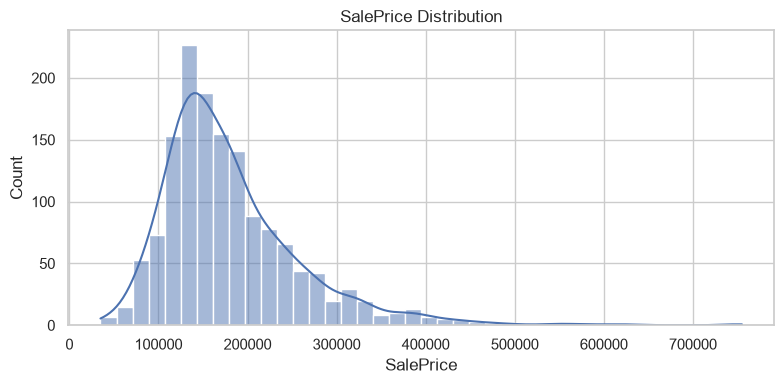

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df['SalePrice'], bins=40, kde=True)
plt.title('SalePrice Distribution')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4) Feature engineering

We derive core valuation features:
- Property age at sale
- Years since remodel
- Total finished area proxies
- Total bath equivalents
- Quality-area interaction
- Log transform for skewed lot/area features

In [5]:
def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()

    # Numeric coercions for key fields used in engineered features.
    for c in [
        'YearBuilt', 'YearRemodAdd', 'YrSold', 'MoSold',
        'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
        'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
        'LotArea', 'OverallQual',
    ]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')

    out['property_age_at_sale'] = out['YrSold'] - out['YearBuilt']
    out['years_since_remodel'] = out['YrSold'] - out['YearRemodAdd']

    out['total_finished_sf'] = out[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']].sum(axis=1, min_count=1)

    out['total_bath_equiv'] = (
        out.get('FullBath', 0).fillna(0)
        + 0.5 * out.get('HalfBath', 0).fillna(0)
        + out.get('BsmtFullBath', 0).fillna(0)
        + 0.5 * out.get('BsmtHalfBath', 0).fillna(0)
    )

    out['quality_x_livarea'] = out.get('OverallQual', np.nan) * out.get('GrLivArea', np.nan)

    out['lotarea_log1p'] = np.log1p(out.get('LotArea', np.nan).clip(lower=0))
    out['grlivarea_log1p'] = np.log1p(out.get('GrLivArea', np.nan).clip(lower=0))

    # Derived categorical seasonality proxy.
    if 'MoSold' in out.columns:
        out['sale_season'] = pd.cut(
            out['MoSold'],
            bins=[0, 3, 6, 9, 12],
            labels=['winter', 'spring', 'summer', 'fall'],
        ).astype(object)

    return out


feature_df = engineer_features(df)
feature_df[['property_id', 'SalePrice', 'property_age_at_sale', 'total_finished_sf', 'total_bath_equiv', 'quality_x_livarea']].head()

,property_id,SalePrice,property_age_at_sale,total_finished_sf,total_bath_equiv,quality_x_livarea
0,0,208500,5,2566,3.5,11970
1,1,181500,31,2524,2.5,7572
2,2,223500,7,2706,3.5,12502
3,3,140000,91,2473,2.0,12019
4,4,250000,8,3343,3.5,17584


## 5) Split train/validation/test with target-distribution stratification

For regression, we stratify on quantile bins of `SalePrice` to preserve price distribution across splits.

In [6]:
TARGET_COL = 'SalePrice'
META_COLS = ['property_id', 'SalePrice']
DROP_ID_COLS = ['property_id', 'Id']


def make_target_bins(y: pd.Series, n_bins: int = 10) -> pd.Series:
    y = pd.Series(y)
    q = min(n_bins, int(y.nunique()))
    if q < 2:
        return pd.Series(np.zeros(len(y), dtype=int), index=y.index)
    return pd.qcut(y.rank(method='first'), q=q, labels=False, duplicates='drop')


def cap_split_rows(df_split: pd.DataFrame, max_rows: int, seed: int, min_rows: int = 100) -> pd.DataFrame:
    if max_rows == 0 or len(df_split) <= max_rows:
        return df_split.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    if max_rows <= min_rows:
        raise ValueError(f'max_rows must be > {min_rows} when capping splits')

    bins = make_target_bins(df_split[TARGET_COL], n_bins=10)
    _, sampled = train_test_split(
        df_split,
        test_size=max_rows,
        random_state=seed,
        stratify=bins,
    )
    return sampled.reset_index(drop=True)


strata = make_target_bins(feature_df[TARGET_COL], n_bins=10)
train_full, holdout = train_test_split(
    feature_df,
    test_size=0.30,
    random_state=SEED,
    stratify=strata,
)
holdout_strata = make_target_bins(holdout[TARGET_COL], n_bins=8)
val_full, test_full = train_test_split(
    holdout,
    test_size=0.50,
    random_state=SEED,
    stratify=holdout_strata,
)

train_df = cap_split_rows(train_full, SAMPLE_TRAIN_ROWS, seed=SEED + 1)
val_df = cap_split_rows(val_full, SAMPLE_EVAL_ROWS, seed=SEED + 2)
test_df = cap_split_rows(test_full, SAMPLE_EVAL_ROWS, seed=SEED + 3)

split_report = []
for name, frame in [('train', train_df), ('val', val_df), ('test', test_df)]:
    split_report.append({
        'split': name,
        'rows': int(len(frame)),
        'price_mean': float(frame[TARGET_COL].mean()),
        'price_median': float(frame[TARGET_COL].median()),
        'price_std': float(frame[TARGET_COL].std()),
    })

pd.DataFrame(split_report)

,split,rows,price_mean,price_median,price_std
0,train,1022,181407.794521,163000.0,80289.221573
1,val,219,181076.853881,163000.0,85110.249970
2,test,219,178494.744292,163990.0,69252.346901


## 6) Modeling helpers and XGBoost baseline

In [7]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    denom = np.maximum(np.abs(y_true), 1.0)
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)
    med_ape = float(np.median(np.abs((y_true - y_pred) / denom)) * 100.0)

    return {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mape_pct': mape,
        'median_ape_pct': med_ape,
    }


def make_model_xy(frame: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray, pd.DataFrame]:
    y = pd.to_numeric(frame[TARGET_COL], errors='coerce').to_numpy(dtype=float)
    meta = frame[[c for c in META_COLS if c in frame.columns]].reset_index(drop=True)

    X = frame.drop(columns=[TARGET_COL]).copy()

    for c in DROP_ID_COLS:
        if c in X.columns:
            X = X.drop(columns=[c])

    X = X.where(pd.notna(X), np.nan)

    # Normalize non-numeric dtypes for stable downstream handling.
    non_numeric_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
    for c in non_numeric_cols:
        X[c] = X[c].astype(object)

    return X, y, meta


X_train, y_train, train_meta = make_model_xy(train_df)
X_val, y_val, val_meta = make_model_xy(val_df)
X_test, y_test, test_meta = make_model_xy(test_df)

num_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
cat_cols = [c for c in X_train.columns if c not in num_cols]

logger.info('Feature columns total={} num={} cat={}', len(X_train.columns), len(num_cols), len(cat_cols))


def train_xgboost_baseline(X: pd.DataFrame, y: np.ndarray) -> Pipeline:
    preprocess = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
            ]), cat_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.04,
        max_depth=6,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist',
        objective='reg:squarederror',
    )

    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model),
    ])
    pipe.fit(X, y)
    return pipe


def get_regression_preds(model: Any, X: pd.DataFrame) -> np.ndarray:
    return np.asarray(model.predict(X)).astype(float)


t0 = time.time()
xgb_model = train_xgboost_baseline(X_train, y_train)
logger.info('XGBoost training completed in {:.1f}s', time.time() - t0)

2026-07-03 03:57:28.583 | INFO     | __main__:<module>:49 - Feature columns total=87 num=43 cat=44


2026-07-03 03:57:28.992 | INFO     | __main__:<module>:93 - XGBoost training completed in 0.4s


## 7) TabFM regression model loading

By default, TabFM will download regression weights from Hugging Face cache on first run.
If `TABFM_CHECKPOINT_PATH` is provided, it is tried first.

In [8]:
def load_tabfm_backbone(device: str) -> Any:
    # Try override path first (if provided), then fallback to default cached download.
    if TABFM_CKPT_PATH is not None:
        try:
            logger.info('Trying TabFM checkpoint override at {}', TABFM_CKPT_PATH)
            return tabfm_v1_0_0.load(
                model_type='regression',
                checkpoint_path=str(TABFM_CKPT_PATH),
                device=device,
            )
        except Exception as exc:
            logger.warning('Checkpoint override failed ({}). Falling back to default download/cache.', exc)

    return tabfm_v1_0_0.load(
        model_type='regression',
        checkpoint_path=None,
        device=device,
    )

## 8) Train 3 TabFM regressors

Variants:
1. `tabfm_default`
2. `tabfm_ensemble_preset`
3. `tabfm_advanced_custom`

Runtime controls:
- `TABFM_CONTEXT_MAX_ROWS` limits fit context size
- `TABFM_EVAL_MAX_ROWS` can limit model-comparison rows
- `TABFM_FAST_MODE=1` uses lighter estimator settings

In [9]:
def pick_tabfm_device(requested: str) -> str:
    if requested.startswith('cuda') and torch.cuda.is_available():
        total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
        logger.info('Detected GPU memory {:.2f} GiB', total_mem_gb)
        if total_mem_gb < 12:
            logger.warning('GPU memory <12 GiB; forcing CPU for TabFM stability')
            return 'cpu'
    return requested


def fit_tabfm_variants(X: pd.DataFrame, y: np.ndarray, requested_device: str) -> dict[str, TabFMRegressor]:
    device = pick_tabfm_device(requested_device)

    if len(X) > TABFM_CONTEXT_MAX_ROWS:
        bins = make_target_bins(pd.Series(y), n_bins=8)
        X_fit, _, y_fit, _ = train_test_split(
            X,
            y,
            train_size=TABFM_CONTEXT_MAX_ROWS,
            random_state=SEED,
            stratify=bins,
        )
        logger.warning('TabFM context capped: {} -> {} rows', len(X), len(X_fit))
    else:
        X_fit, y_fit = X, y

    batch_size = 1 if device == 'cpu' else 2

    if TABFM_FAST_MODE:
        logger.warning('TABFM_FAST_MODE=1 enabled; reduced estimator complexity active')
        default_estimators = 2
        ensemble_estimators = 2
        advanced_estimators = 2
        advanced_norm_methods = ['none']
        advanced_n_feature_crosses = 0
        advanced_n_svd_features = 0
        advanced_total_svd_pool = 32
    else:
        default_estimators = 4
        ensemble_estimators = 6
        advanced_estimators = 6
        advanced_norm_methods = ['none', 'power', 'quantile_rtdl']
        advanced_n_feature_crosses = 'sqrt'
        advanced_n_svd_features = 'sqrt'
        advanced_total_svd_pool = 128

    models: dict[str, TabFMRegressor] = {}

    m_default = TabFMRegressor(
        model=load_tabfm_backbone(device),
        n_estimators=default_estimators,
        batch_size=batch_size,
        random_state=SEED,
        n_feature_crosses=0,
        n_svd_features=0,
        enable_nnls=False,
        verbose=False,
    )
    m_default.fit(X_fit, y_fit)
    models['tabfm_default'] = m_default

    m_ensemble = TabFMRegressor.ensemble(
        model=load_tabfm_backbone(device),
        n_estimators=ensemble_estimators,
        batch_size=batch_size,
        random_state=SEED,
        num_folds_for_cv=2,
        min_rows_for_single_val_split=100,
        verbose=False,
    )
    m_ensemble.fit(X_fit, y_fit)
    models['tabfm_ensemble_preset'] = m_ensemble

    m_advanced = TabFMRegressor(
        model=load_tabfm_backbone(device),
        n_estimators=advanced_estimators,
        norm_methods=advanced_norm_methods,
        feat_shuffle_method='random',
        permute_categorical=True,
        n_feature_crosses=advanced_n_feature_crosses,
        n_svd_features=advanced_n_svd_features,
        total_svd_pool=advanced_total_svd_pool,
        enable_nnls=False,
        random_state=SEED,
        batch_size=batch_size,
        num_folds_for_cv=2,
        min_rows_for_single_val_split=100,
        verbose=False,
    )
    m_advanced.fit(X_fit, y_fit)
    models['tabfm_advanced_custom'] = m_advanced

    logger.info('TabFM variants trained on device={}', device)
    return models


t1 = time.time()
tabfm_models = fit_tabfm_variants(X_train, y_train, requested_device=DEVICE)
logger.info('TabFM training completed in {:.1f}s', time.time() - t1)

2026-07-03 03:57:29.004 | INFO     | __main__:pick_tabfm_device:4 - Detected GPU memory 7.62 GiB


2026-07-03 03:57:29.005 | WARNING  | __main__:pick_tabfm_device:6 - GPU memory <12 GiB; forcing CPU for TabFM stability


2026-07-03 03:57:29.009 | WARNING  | __main__:fit_tabfm_variants:23 - TabFM context capped: 1022 -> 650 rows


2026-07-03 03:57:29.010 | WARNING  | __main__:fit_tabfm_variants:30 - TABFM_FAST_MODE=1 enabled; reduced estimator complexity active


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

2026-07-03 04:06:49.611 | INFO     | __main__:fit_tabfm_variants:93 - TabFM variants trained on device=cpu


2026-07-03 04:06:49.612 | INFO     | __main__:<module>:99 - TabFM training completed in 560.6s


## 9) Evaluate models and pick champion

In [10]:
def build_eval_slice(X: pd.DataFrame, y: np.ndarray, max_rows: int, seed_offset: int) -> tuple[pd.DataFrame, np.ndarray]:
    if max_rows == 0 or len(X) <= max_rows:
        return X, y

    bins = make_target_bins(pd.Series(y), n_bins=8)
    _, X_sampled, _, y_sampled = train_test_split(
        X,
        y,
        test_size=max_rows,
        random_state=SEED + seed_offset,
        stratify=bins,
    )
    return X_sampled, y_sampled


X_val_eval, y_val_eval = build_eval_slice(X_val, y_val, TABFM_EVAL_MAX_ROWS, seed_offset=101)
X_test_eval, y_test_eval = build_eval_slice(X_test, y_test, TABFM_EVAL_MAX_ROWS, seed_offset=202)
logger.info('Evaluation rows used (val/test): {}/{}', len(X_val_eval), len(X_test_eval))

model_registry: dict[str, Any] = {'xgboost_baseline': xgb_model, **tabfm_models}
rows: list[dict[str, Any]] = []
predictions: dict[str, dict[str, np.ndarray]] = {}

for model_name, model in model_registry.items():
    val_pred = get_regression_preds(model, X_val_eval)
    test_pred = get_regression_preds(model, X_test_eval)
    predictions[model_name] = {'val': val_pred, 'test': test_pred}

    rows.append({'model': model_name, 'split': 'val', **regression_metrics(y_val_eval, val_pred)})
    rows.append({'model': model_name, 'split': 'test', **regression_metrics(y_test_eval, test_pred)})

metrics_df = pd.DataFrame(rows)
val_rank = metrics_df[metrics_df['split'] == 'val'].sort_values('rmse', ascending=True).reset_index(drop=True)
champion_model_name = val_rank.loc[0, 'model']
logger.info('Champion model by validation RMSE: {}', champion_model_name)

# Full-score champion for downstream pricing policy.
champion_model = model_registry[champion_model_name]
champion_val_pred = get_regression_preds(champion_model, X_val)
champion_test_pred = get_regression_preds(champion_model, X_test)
logger.info('Champion full prediction rows (val/test): {}/{}', len(champion_val_pred), len(champion_test_pred))

metrics_df.sort_values(['split', 'rmse'], ascending=[True, True]).reset_index(drop=True)

2026-07-03 04:06:49.618 | INFO     | __main__:<module>:18 - Evaluation rows used (val/test): 219/219


2026-07-03 04:10:23.315 | INFO     | __main__:<module>:35 - Champion model by validation RMSE: tabfm_default


2026-07-03 04:11:24.483 | INFO     | __main__:<module>:41 - Champion full prediction rows (val/test): 219/219


,model,split,rmse,mae,r2,mape_pct,median_ape_pct
0,tabfm_ensemble_preset,test,23521.121125,15047.538200,0.884113,9.351970,5.682727
1,tabfm_default,test,24008.319973,15397.572489,0.879263,9.521368,5.947450
2,tabfm_advanced_custom,test,24414.608574,15624.639448,0.875141,9.527992,5.984111
3,xgboost_baseline,test,24815.072235,16444.075931,0.871012,10.424758,5.853270
4,tabfm_default,val,18641.478248,12618.544592,0.951807,8.219528,5.409451
5,tabfm_ensemble_preset,val,18992.298847,12774.838328,0.949976,8.290124,5.135857
6,tabfm_advanced_custom,val,19177.528577,12865.746433,0.948995,8.299450,5.307519
7,xgboost_baseline,val,24879.691237,14210.979630,0.914155,8.886819,5.235789


/tmp/ipykernel_337489/2540231330.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='rmse', y='model', ax=axes[0], palette='viridis')
/tmp/ipykernel_337489/2540231330.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='r2', y='model', ax=axes[1], palette='mako')


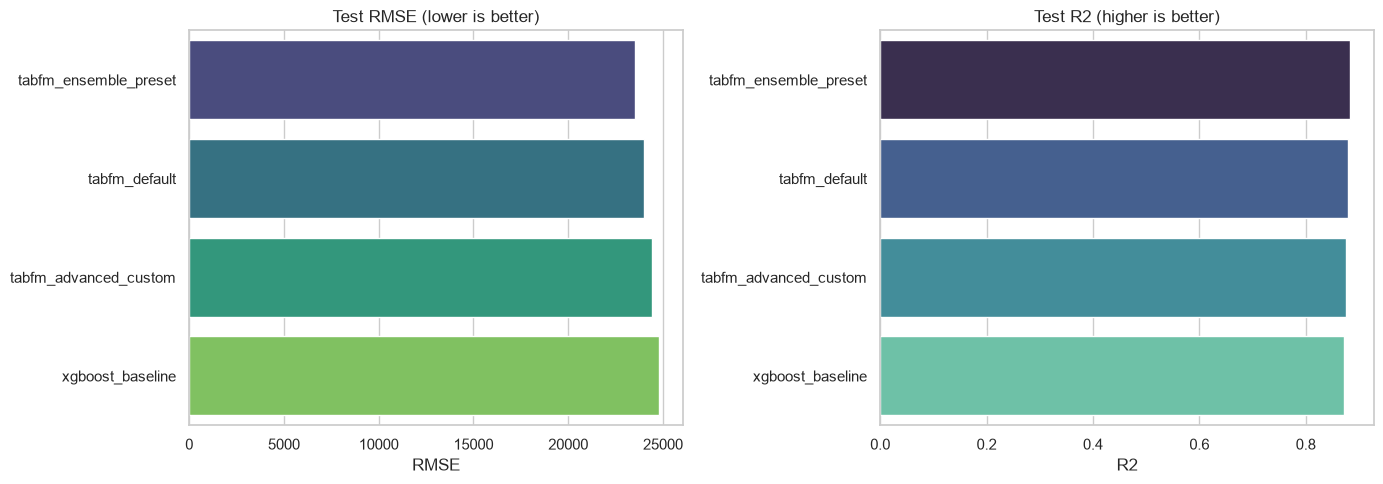

In [11]:
plot_df = metrics_df[metrics_df['split'] == 'test'].sort_values('rmse', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=plot_df, x='rmse', y='model', ax=axes[0], palette='viridis')
axes[0].set_title('Test RMSE (lower is better)')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('')

sns.barplot(data=plot_df, x='r2', y='model', ax=axes[1], palette='mako')
axes[1].set_title('Test R2 (higher is better)')
axes[1].set_xlabel('R2')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

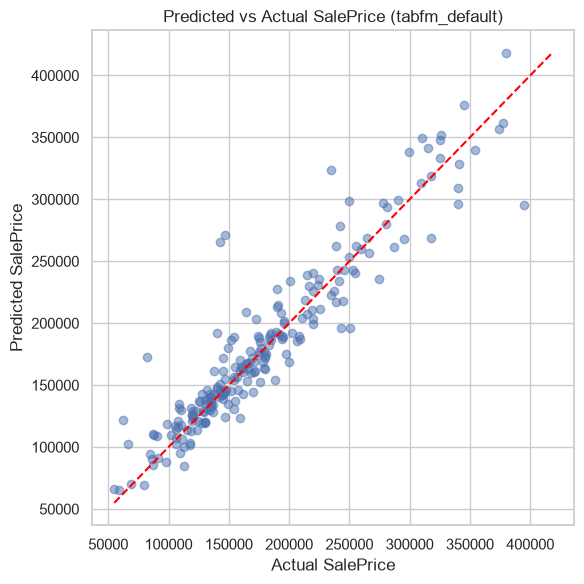

In [12]:
pred_vs_actual = pd.DataFrame({
    'actual': y_test,
    'predicted': champion_test_pred,
})

plt.figure(figsize=(6, 6))
plt.scatter(pred_vs_actual['actual'], pred_vs_actual['predicted'], alpha=0.5)
low = min(pred_vs_actual['actual'].min(), pred_vs_actual['predicted'].min())
high = max(pred_vs_actual['actual'].max(), pred_vs_actual['predicted'].max())
plt.plot([low, high], [low, high], '--', color='red')
plt.title(f'Predicted vs Actual SalePrice ({champion_model_name})')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.tight_layout()
plt.show()

## 10) Valuation confidence bands and automation policy

We estimate uncertainty from:
1. Validation absolute percentage error quantiles
2. Cross-model prediction disagreement on test rows

Then assign an operational automation tier:
- `auto_quote`: low uncertainty
- `analyst_review`: medium uncertainty
- `senior_appraiser_review`: high uncertainty

In [13]:
val_ape = np.abs((y_val - champion_val_pred) / np.maximum(np.abs(y_val), 1.0))
q50, q80, q90 = np.quantile(val_ape, [0.50, 0.80, 0.90])
logger.info('Validation APE quantiles q50={:.3f} q80={:.3f} q90={:.3f}', q50, q80, q90)

# Collect full test predictions from all models for disagreement-based uncertainty.
full_test_preds_all = {}
for model_name, model in model_registry.items():
    full_test_preds_all[model_name] = get_regression_preds(model, X_test)

pred_matrix = np.vstack([full_test_preds_all[k] for k in sorted(full_test_preds_all.keys())])
disagreement_pct = np.std(pred_matrix, axis=0) / np.maximum(np.abs(np.mean(pred_matrix, axis=0)), 1.0)

test_pricing = test_meta.copy()
test_pricing['actual_sale_price'] = y_test
test_pricing['predicted_sale_price'] = champion_test_pred
test_pricing['abs_error'] = np.abs(test_pricing['actual_sale_price'] - test_pricing['predicted_sale_price'])
test_pricing['abs_pct_error'] = np.abs((test_pricing['actual_sale_price'] - test_pricing['predicted_sale_price']) / np.maximum(np.abs(test_pricing['actual_sale_price']), 1.0))

test_pricing['pred_lower_q80'] = test_pricing['predicted_sale_price'] * (1.0 - q80)
test_pricing['pred_upper_q80'] = test_pricing['predicted_sale_price'] * (1.0 + q80)
test_pricing['pred_interval_width_pct'] = 2.0 * q80
test_pricing['model_disagreement_pct'] = disagreement_pct

d1 = float(np.quantile(disagreement_pct, 0.50))
d2 = float(np.quantile(disagreement_pct, 0.85))

test_pricing['valuation_tier'] = np.select(
    [
        test_pricing['model_disagreement_pct'] <= d1,
        test_pricing['model_disagreement_pct'] <= d2,
    ],
    [
        'auto_quote',
        'analyst_review',
    ],
    default='senior_appraiser_review',
)

coverage_q80 = float(
    ((test_pricing['actual_sale_price'] >= test_pricing['pred_lower_q80'])
     & (test_pricing['actual_sale_price'] <= test_pricing['pred_upper_q80'])).mean()
)
logger.info('Empirical test coverage for q80 interval: {:.2%}', coverage_q80)

policy_summary = (
    test_pricing.groupby('valuation_tier', dropna=False)
    .agg(
        properties=('property_id', 'count'),
        avg_pred_price=('predicted_sale_price', 'mean'),
        mean_abs_pct_error=('abs_pct_error', 'mean'),
        mean_disagreement_pct=('model_disagreement_pct', 'mean'),
    )
    .reset_index()
    .sort_values('properties', ascending=False)
)

policy_summary

2026-07-03 04:11:24.779 | INFO     | __main__:<module>:3 - Validation APE quantiles q50=0.054 q80=0.108 q90=0.165


2026-07-03 04:13:02.619 | INFO     | __main__:<module>:43 - Empirical test coverage for q80 interval: 73.06%


,valuation_tier,properties,avg_pred_price,mean_abs_pct_error,mean_disagreement_pct
1,auto_quote,110,178128.402273,0.077379,0.009788
0,analyst_review,76,187478.970189,0.099915,0.024722
2,senior_appraiser_review,33,177704.132576,0.143836,0.069365


In [14]:
top_uncertain = test_pricing.sort_values('model_disagreement_pct', ascending=False).head(20)
top_uncertain[['property_id', 'predicted_sale_price', 'actual_sale_price', 'abs_pct_error', 'model_disagreement_pct', 'valuation_tier']]

,property_id,predicted_sale_price,actual_sale_price,abs_pct_error,model_disagreement_pct,valuation_tier
114,137,160849.625000,171000.0,0.059359,0.174819,senior_appraiser_review
58,676,85286.804688,87000.0,0.019692,0.138606,senior_appraiser_review
214,1039,69266.234375,80000.0,0.134172,0.124521,senior_appraiser_review
5,705,66204.656250,55000.0,0.203721,0.106435,senior_appraiser_review
71,662,129993.570312,110000.0,0.181760,0.088990,senior_appraiser_review
67,588,265774.718750,143000.0,0.858564,0.088867,senior_appraiser_review
103,489,90415.984375,86000.0,0.051349,0.083962,senior_appraiser_review
138,1391,113433.250000,124000.0,0.085216,0.083759,senior_appraiser_review
53,1380,65074.953125,58500.0,0.112392,0.083618,senior_appraiser_review
180,441,103081.968750,118000.0,0.126424,0.076451,senior_appraiser_review


## 11) Persist artifacts

In [15]:
metrics_path = ARTIFACT_DIR / 'problem5_houseprice_model_metrics.csv'
pred_path = ARTIFACT_DIR / 'problem5_houseprice_predictions_test.parquet'
policy_path = ARTIFACT_DIR / 'problem5_houseprice_policy_actions.csv'
policy_summary_path = ARTIFACT_DIR / 'problem5_houseprice_policy_summary.csv'
runtime_meta_path = ARTIFACT_DIR / 'problem5_houseprice_runtime_meta.json'

metrics_df.to_csv(metrics_path, index=False)
test_pricing.to_csv(policy_path, index=False)
policy_summary.to_csv(policy_summary_path, index=False)

pred_frame = test_pricing[[
    'property_id',
    'actual_sale_price',
    'predicted_sale_price',
    'pred_lower_q80',
    'pred_upper_q80',
    'abs_pct_error',
    'model_disagreement_pct',
    'valuation_tier',
]].copy()

pred_frame_cast = pred_frame.copy()
for c in ['property_id']:
    pred_frame_cast[c] = pred_frame_cast[c].astype('int64')
for c in ['actual_sale_price', 'predicted_sale_price', 'pred_lower_q80', 'pred_upper_q80', 'abs_pct_error', 'model_disagreement_pct']:
    pred_frame_cast[c] = pred_frame_cast[c].astype('float64')
pred_frame_cast['valuation_tier'] = pred_frame_cast['valuation_tier'].astype(str)

pl.DataFrame({col: pred_frame_cast[col].tolist() for col in pred_frame_cast.columns}).write_parquet(pred_path)

runtime_meta = {
    'seed': SEED,
    'openml_data_id': OPENML_DATA_ID,
    'sample_train_rows': int(SAMPLE_TRAIN_ROWS),
    'sample_eval_rows': int(SAMPLE_EVAL_ROWS),
    'tabfm_context_max_rows': int(TABFM_CONTEXT_MAX_ROWS),
    'tabfm_eval_max_rows': int(TABFM_EVAL_MAX_ROWS),
    'tabfm_fast_mode': bool(TABFM_FAST_MODE),
    'tabfm_device_preference': TABFM_DEVICE_PREF,
    'tabfm_device_effective': DEVICE,
    'tabfm_checkpoint_override': str(TABFM_CKPT_PATH) if TABFM_CKPT_PATH else None,
    'champion_model': champion_model_name,
    'val_ape_quantiles': {
        'q50': float(q50),
        'q80': float(q80),
        'q90': float(q90),
    },
    'q80_interval_coverage_test': coverage_q80,
}
runtime_meta_path.write_text(json.dumps(runtime_meta, indent=2))

for p in [metrics_path, pred_path, policy_path, policy_summary_path, runtime_meta_path]:
    logger.info('Wrote {}', p)

sorted(p.name for p in ARTIFACT_DIR.glob('problem5_houseprice_*'))

2026-07-03 04:13:02.656 | INFO     | __main__:<module>:53 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem5_house_price_prediction/artifacts/problem5_houseprice_model_metrics.csv


2026-07-03 04:13:02.656 | INFO     | __main__:<module>:53 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem5_house_price_prediction/artifacts/problem5_houseprice_predictions_test.parquet


2026-07-03 04:13:02.656 | INFO     | __main__:<module>:53 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem5_house_price_prediction/artifacts/problem5_houseprice_policy_actions.csv


2026-07-03 04:13:02.657 | INFO     | __main__:<module>:53 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem5_house_price_prediction/artifacts/problem5_houseprice_policy_summary.csv


2026-07-03 04:13:02.657 | INFO     | __main__:<module>:53 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem5_house_price_prediction/artifacts/problem5_houseprice_runtime_meta.json


['problem5_houseprice_model_metrics.csv',
 'problem5_houseprice_policy_actions.csv',
 'problem5_houseprice_policy_summary.csv',
 'problem5_houseprice_predictions_test.parquet',
 'problem5_houseprice_runtime_meta.json']

## 12) Deployment notes

Recommended next steps:
1. Add time-based backtesting by sale year (`YrSold`) to simulate market drift.
2. Incorporate external trend signals (interest rates, regional indices).
3. Calibrate confidence bands by neighborhood/price segment.
4. Add monitoring for residual drift and uncertainty drift post-deployment.